# ResNet18 Cuneiform Sign Classification: Single-Image Inference

This notebook performs inference on one local image using:

`~/erc-work-data/signs_alignment_data/best_resnet18_sign_classifier.pth`

Run the cells in order. The final cell prompts for an image path and displays both the image and its Top-K predictions. Select `/home/dssuser/cuneiform-ocr/bin/python` as the notebook kernel.

> The checkpoint is a plain `state_dict` with 482 output classes and does not contain class names. Predictions are therefore displayed as class indices such as `class_000`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

CHECKPOINT_PATH = Path(
    "~/erc-work-data/signs_alignment_data/best_resnet18_sign_classifier.pth"
).expanduser().resolve()
TOP_K = 5

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

PyTorch: 2.0.1+cu117
Device: cuda
Checkpoint: /dss/pn34bu-dss-0000/work-data/signs_alignment_data/best_resnet18_sign_classifier.pth


In [2]:
def load_checkpoint(path):
    # Use safe weight-only loading when supported by the installed PyTorch version.
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")


checkpoint = load_checkpoint(CHECKPOINT_PATH)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

if not isinstance(state_dict, dict):
    raise TypeError("The checkpoint does not contain a usable state_dict")

# Support checkpoints saved from a DataParallel model.
if state_dict and all(key.startswith("module.") for key in state_dict):
    state_dict = {key.removeprefix("module."): value for key, value in state_dict.items()}

if "fc.weight" not in state_dict:
    raise KeyError("The checkpoint has no fc.weight entry; the class count cannot be determined")

NUM_CLASSES = int(state_dict["fc.weight"].shape[0])

# Avoid downloading ImageNet weights; all parameters come from the local checkpoint.
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.load_state_dict(state_dict, strict=True)
model = model.to(DEVICE).eval()

print(f"Loaded ResNet18 with {NUM_CLASSES} output classes")

/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Loaded ResNet18 with 482 output classes


In [3]:
inference_transform = transforms.Compose([
    transforms.Resize((232, 232)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])


@torch.inference_mode()
def predict_image(image_path, top_k=TOP_K):
    image_path = Path(image_path).expanduser().resolve()
    if not image_path.is_file():
        raise FileNotFoundError(f"Image not found: {image_path}")

    with Image.open(image_path) as source_image:
        image = source_image.convert("RGB")

    input_tensor = inference_transform(image).unsqueeze(0).to(DEVICE)
    logits = model(input_tensor)
    probabilities = torch.softmax(logits, dim=1)[0]

    effective_top_k = min(max(int(top_k), 1), NUM_CLASSES)
    top_probabilities, top_indices = probabilities.topk(effective_top_k)

    predictions = pd.DataFrame({
        "rank": range(1, effective_top_k + 1),
        "class_index": top_indices.cpu().tolist(),
        "label": [f"class_{index:03d}" for index in top_indices.cpu().tolist()],
        "probability": top_probabilities.cpu().tolist(),
    })

    return image_path, image, predictions

## Run inference

Run the cell below and enter the full path to one image when prompted.

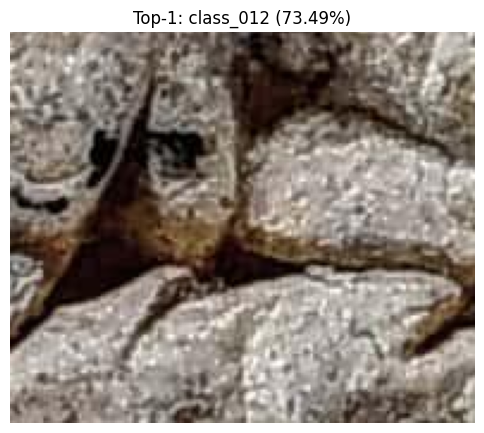

Image: /dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree/alignment_results/CBS.1499_det_box_0.png


,rank,class_index,label,probability
0,1,12,class_012,73.49%
1,2,8,class_008,7.73%
2,3,10,class_010,0.32%
3,4,191,class_191,0.32%
4,5,131,class_131,0.24%


In [4]:
image_path_input = "alignment_results/CBS.1499_det_box_0.png"
if not image_path_input:
    raise ValueError("An image path is required")

image_path, image, predictions = predict_image(image_path_input)
top_prediction = predictions.iloc[0]

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(
    f"Top-1: {top_prediction['label']} "
    f"({top_prediction['probability']:.2%})"
)
plt.axis("off")
plt.show()

print(f"Image: {image_path}")
display(predictions.style.format({"probability": "{:.2%}"}))